In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df=pd.read_csv("houses_flats.csv")

In [51]:
df.shape

(23081, 22)

In [52]:
df.head()

,bedrooms,baths,price,area_sqft,kitchens,store_rooms,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floors,agePossession,property_type,has_servant_room
0,4.0,4.0,4.55,3264.0,1.0,1.0,1,1,1,1,1,1,1,0,0,0,135.0,37,3.0,New Property,0,1
1,4.0,5.0,4.50,3318.4,1.0,0.0,1,1,0,0,1,1,0,0,0,1,150.0,31,3.0,New Property,0,1
2,3.0,4.0,3.55,2720.0,1.0,1.0,1,1,1,1,1,1,1,1,1,1,156.0,49,3.0,New Property,0,1
3,4.0,4.0,4.45,2067.2,2.0,1.0,1,1,0,0,1,0,0,0,0,1,125.0,18,3.0,New Property,0,1
4,4.0,5.0,4.65,3318.4,1.0,1.0,1,1,0,0,1,1,0,0,0,1,100.0,18,3.0,New Property,0,1


In [53]:
df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'drawing_room', 'dining_room', 'lounge_or_sitting_room', 'laundry_room',
       'study_room', 'prayer_room', 'powder_room', 'gym', 'steam_room',
       'other_rooms', 'luxury_score', 'furnishing_score', 'floors',
       'agePossession', 'property_type', 'has_servant_room'],
      dtype='object')

## EDA

In [54]:
pd.set_option("display.max_columns", None)

In [55]:
df['property_type'].value_counts()

property_type
1    20047
0     3034
Name: count, dtype: int64

In [56]:
df.groupby('property_type')['price'].describe()
df.groupby('property_type')['area_sqft'].describe()

,count,mean,std,min,25%,50%,75%,max
property_type,,,,,,,,
0,3034.0,1561.409097,1061.044405,108.8000,625.600,1142.40,2720.00,5440.00
1,20047.0,3441.237973,2606.018088,408.3765,1361.255,2722.51,5445.02,19057.57


In [57]:
df.shape

(23081, 22)

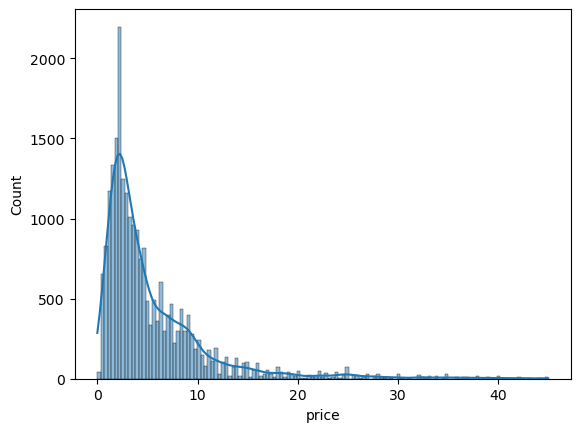

In [58]:
sns.histplot(df['price'], kde=True)  # distplot is deprecated
plt.show()

<Axes: xlabel='price'>

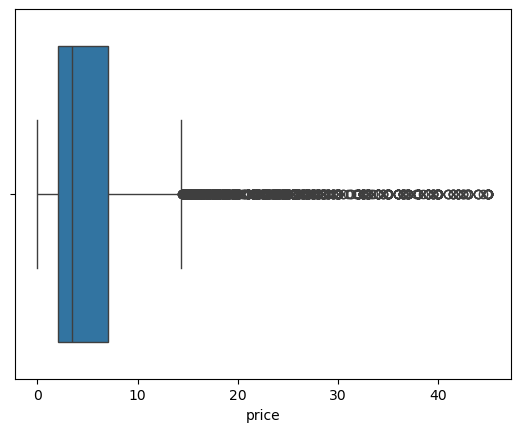

In [59]:
sns.boxplot(x=df['price'])

<Axes: xlabel='area_sqft', ylabel='Count'>

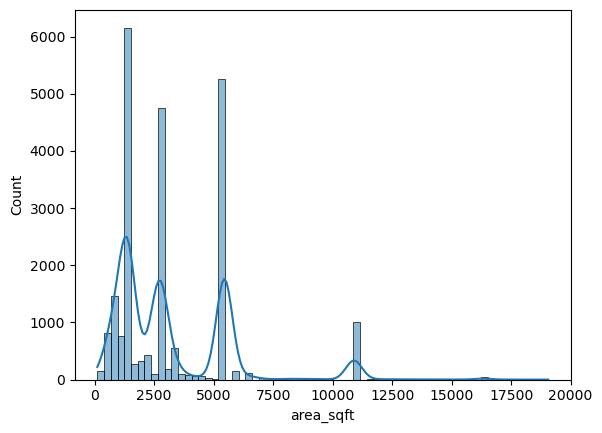

In [60]:
sns.histplot(df["area_sqft"], kde=True)

<Axes: xlabel='area_sqft'>

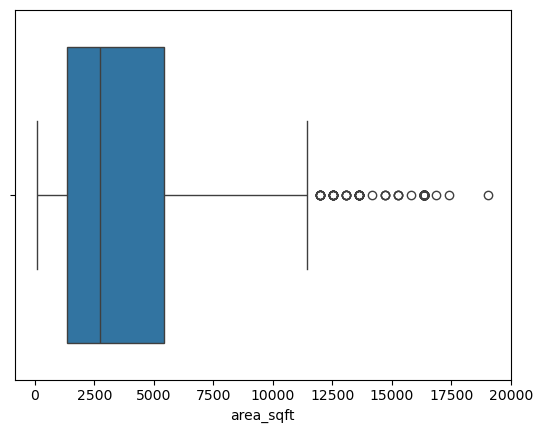

In [61]:
sns.boxplot(x=df["area_sqft"])


In [62]:
train_df=df.copy()

In [63]:
train_df.head()

,bedrooms,baths,price,area_sqft,kitchens,store_rooms,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floors,agePossession,property_type,has_servant_room
0,4.0,4.0,4.55,3264.0,1.0,1.0,1,1,1,1,1,1,1,0,0,0,135.0,37,3.0,New Property,0,1
1,4.0,5.0,4.50,3318.4,1.0,0.0,1,1,0,0,1,1,0,0,0,1,150.0,31,3.0,New Property,0,1
2,3.0,4.0,3.55,2720.0,1.0,1.0,1,1,1,1,1,1,1,1,1,1,156.0,49,3.0,New Property,0,1
3,4.0,4.0,4.45,2067.2,2.0,1.0,1,1,0,0,1,0,0,0,0,1,125.0,18,3.0,New Property,0,1
4,4.0,5.0,4.65,3318.4,1.0,1.0,1,1,0,0,1,1,0,0,0,1,100.0,18,3.0,New Property,0,1


In [64]:
train_df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'drawing_room', 'dining_room', 'lounge_or_sitting_room', 'laundry_room',
       'study_room', 'prayer_room', 'powder_room', 'gym', 'steam_room',
       'other_rooms', 'luxury_score', 'furnishing_score', 'floors',
       'agePossession', 'property_type', 'has_servant_room'],
      dtype='object')

<Axes: xlabel='luxury_score'>

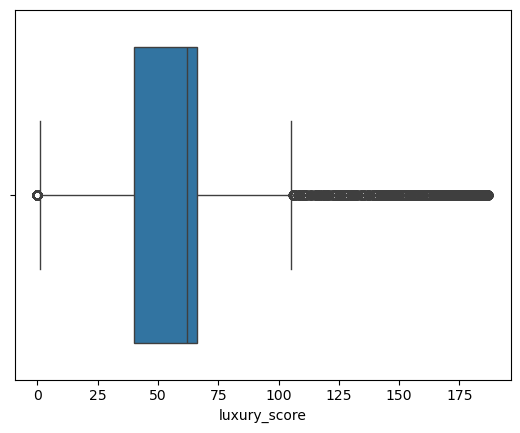

In [65]:
sns.boxplot(x=df['luxury_score'])

In [66]:
q1 = train_df['luxury_score'].quantile(0.25)
q2 = train_df['luxury_score'].quantile(0.50)
q3 = train_df['luxury_score'].quantile(0.75)

def categorize_luxury(score):
    if score < q1:
        return "Low"
    elif score < q2:
        return "Medium"
    elif score < q3:
        return "High"
    else:
        return "Very High"


In [67]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

<Axes: xlabel='floors'>

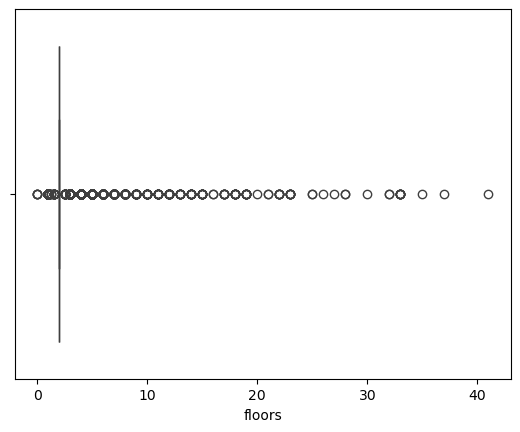

In [68]:
sns.boxplot(x=df['floors'])

In [69]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif floor >= 11:
        return "High Floor"
    else:
        return None

train_df['floor_category'] = train_df['floors'].apply(categorize_floor)

In [70]:
train_df['floor_category'].value_counts()

floor_category
Low Floor     18586
Mid Floor      4329
High Floor      134
Name: count, dtype: int64

In [71]:
train_df.drop(columns=['floors', 'luxury_score'], inplace=True)

In [72]:
train_df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'drawing_room', 'dining_room', 'lounge_or_sitting_room', 'laundry_room',
       'study_room', 'prayer_room', 'powder_room', 'gym', 'steam_room',
       'other_rooms', 'furnishing_score', 'agePossession', 'property_type',
       'has_servant_room', 'luxury_category', 'floor_category'],
      dtype='object')

In [31]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()

categorical_cols = data_label_encoded.select_dtypes(include=['object']).columns

oe = OrdinalEncoder()
data_label_encoded[categorical_cols] = oe.fit_transform(data_label_encoded[categorical_cols])

X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [32]:
X_label

,bedrooms,baths,area_sqft,kitchens,store_rooms,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,furnishing_score,agePossession,property_type,has_servant_room,luxury_category,floor_category
0,4.0,4.0,3264.00,1.0,1.0,1,1,1,1,1,1,1,0,0,0,37,1.0,0,1,3.0,2.0
1,4.0,5.0,3318.40,1.0,0.0,1,1,0,0,1,1,0,0,0,1,31,1.0,0,1,3.0,2.0
2,3.0,4.0,2720.00,1.0,1.0,1,1,1,1,1,1,1,1,1,1,49,1.0,0,1,3.0,2.0
3,4.0,4.0,2067.20,2.0,1.0,1,1,0,0,1,0,0,0,0,1,18,1.0,0,1,3.0,2.0
4,4.0,5.0,3318.40,1.0,1.0,1,1,0,0,1,1,0,0,0,1,18,1.0,0,1,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23076,6.0,7.0,5445.02,2.0,1.0,1,1,1,1,0,0,0,0,0,0,25,3.0,1,1,2.0,1.0
23077,4.0,5.0,5445.02,2.0,2.0,1,1,0,1,0,0,1,0,0,0,15,4.0,1,1,2.0,1.0
23078,6.0,6.0,5445.02,2.0,1.0,1,1,1,1,1,1,1,1,1,0,25,0.0,1,1,3.0,1.0
23079,5.0,6.0,5445.02,3.0,2.0,1,1,0,0,1,1,0,0,0,1,8,3.0,1,1,2.0,1.0


## 8 feature selection techniques

## Technique 1: Correlation Analysis

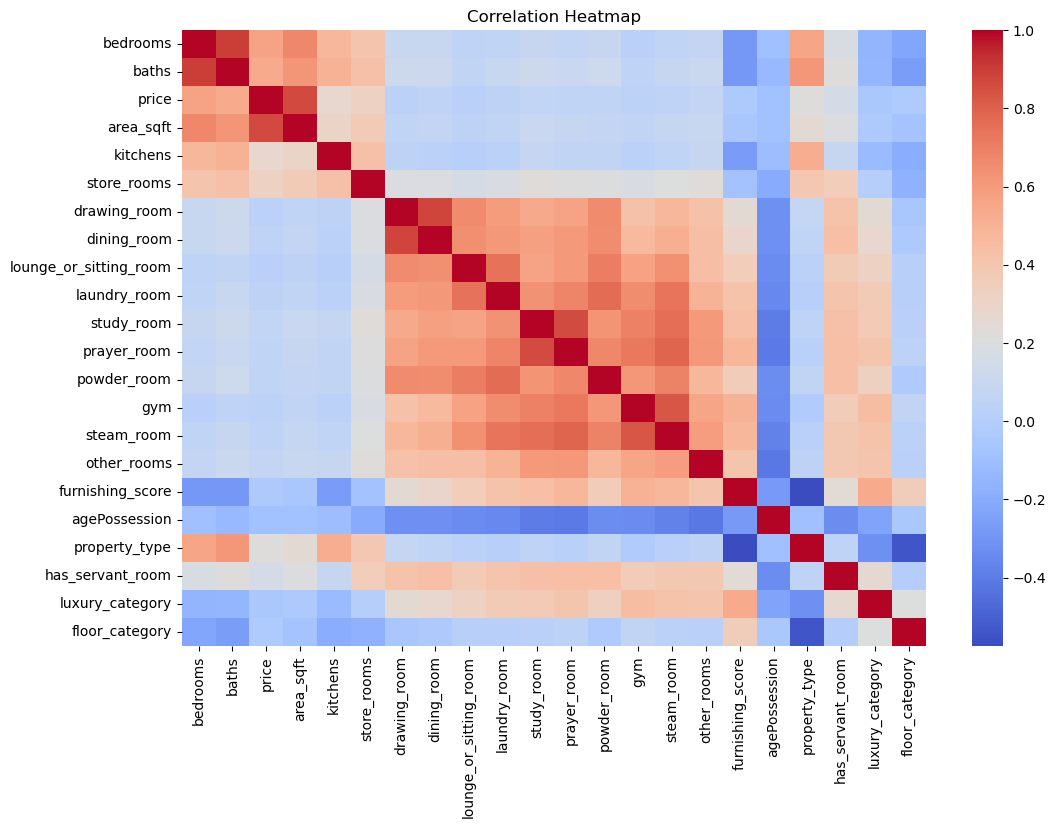

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(data_label_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [34]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index': 'feature', 'price': 'corr_coeff'})
fi_df1.sort_values(by='corr_coeff', ascending=False)

,feature,corr_coeff
1,price,1.000000
2,area_sqft,0.868938
0,baths,0.533989
4,store_rooms,0.321217
3,kitchens,0.276431
17,property_type,0.220545
18,has_servant_room,0.162786
14,other_rooms,0.073048
9,study_room,0.065974
10,prayer_room,0.058209


### 📌 Technique 2: Random Forest Feature Importance


In [35]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
2,area_sqft,0.817981
15,furnishing_score,0.025455
0,bedrooms,0.023663
16,agePossession,0.020866
1,baths,0.019699
3,kitchens,0.015065
19,luxury_category,0.014927
4,store_rooms,0.012333
20,floor_category,0.008738
18,has_servant_room,0.007171


### 📌 Technique 3: Gradient Boosting Feature Importance


In [36]:
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# Train Gradient Boosting Regressor
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
2,area_sqft,0.951427
1,baths,0.017685
15,furnishing_score,0.007790
20,floor_category,0.005333
0,bedrooms,0.005309
16,agePossession,0.004835
3,kitchens,0.001674
19,luxury_category,0.001631
4,store_rooms,0.001288
12,gym,0.001130


### 📌 Technique 3: Gradient Boosting Feature Importance

In [37]:
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# Train Gradient Boosting Regressor
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
2,area_sqft,0.951405
1,baths,0.017681
15,furnishing_score,0.007786
20,floor_category,0.005333
0,bedrooms,0.005307
16,agePossession,0.004835
3,kitchens,0.001702
19,luxury_category,0.001645
4,store_rooms,0.001278
12,gym,0.001130


### 📌 Technique 4: Permutation Importance

Permutation Importance measures how much a model’s performance decreases when a feature’s values are randomly shuffled.  
If shuffling a feature significantly reduces model performance, that feature is important.


In [38]:

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train-test split
X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(
    X_label, y_label, test_size=0.2, random_state=42
)

# Train model
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Compute permutation importance
perm_importance = permutation_importance(
    rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42
)

# Store results
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
2,area_sqft,1.440374
0,bedrooms,0.055428
15,furnishing_score,0.028469
16,agePossession,0.025388
19,luxury_category,0.024280
1,baths,0.021376
18,has_servant_room,0.009729
12,gym,0.009316
3,kitchens,0.009149
20,floor_category,0.007884


### 📌 Technique 5: LASSO (Feature Selection)

LASSO (L1 Regularization) helps in feature selection by shrinking less important feature coefficients to zero.


In [39]:

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train LASSO model
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
2,area_sqft,5.041530
15,furnishing_score,0.405870
17,property_type,0.401055
20,floor_category,0.290254
3,kitchens,0.096293
1,baths,0.092525
4,store_rooms,0.022948
11,powder_room,0.009801
8,laundry_room,0.000000
7,lounge_or_sitting_room,0.000000


### 📌 Technique 6: RFE (Recursive Feature Elimination)

RFE selects important features by recursively removing the least important ones based on a model.


In [40]:

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Initialize model
estimator = RandomForestRegressor()

# Apply RFE
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get selected features
selected_features = X_label.columns[selector_label.support_]

# Get importance scores
selected_coefficients = selector_label.estimator_.feature_importances_

# Store results
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
2,area_sqft,0.818919
15,furnishing_score,0.025994
0,bedrooms,0.023058
16,agePossession,0.020856
1,baths,0.019642
3,kitchens,0.015127
19,luxury_category,0.015067
4,store_rooms,0.012050
20,floor_category,0.008768
18,has_servant_room,0.007107


### 📌 Technique 7: Linear Regression Weights

Linear Regression assigns coefficients (weights) to each feature, indicating their impact on the target variable.

In [41]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
2,area_sqft,5.069131
15,furnishing_score,0.456924
17,property_type,0.446835
20,floor_category,0.312592
1,baths,0.181418
3,kitchens,0.100942
11,powder_room,0.052214
4,store_rooms,0.035839
7,lounge_or_sitting_room,0.027193
6,dining_room,0.012952


In [42]:
final_fi_df = fi_df1.merge(fi_df2, on='feature') \
                   .merge(fi_df3, on='feature') \
                   .merge(fi_df4, on='feature') \
                   .merge(fi_df5, on='feature') \
                   .merge(fi_df6, on='feature') \
                   .merge(fi_df7, on='feature') \
                   .set_index('feature')
                   
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
baths,0.533989,0.019699,0.017681,0.021376,0.092525,0.019642,0.181418
area_sqft,0.868938,0.817981,0.951405,1.440374,5.041530,0.818919,5.069131
kitchens,0.276431,0.015065,0.001702,0.009149,0.096293,0.015127,0.100942
store_rooms,0.321217,0.012333,0.001278,0.005398,0.022948,0.012050,0.035839
drawing_room,0.033413,0.001616,0.000136,0.000666,-0.022590,0.001435,-0.061357
dining_room,0.049040,0.001481,0.000000,0.000583,-0.000000,0.001444,0.012952
lounge_or_sitting_room,0.026278,0.003136,0.000000,-0.000209,0.000000,0.003237,0.027193
laundry_room,0.043601,0.002821,0.000338,0.000011,0.000000,0.002876,-0.003828
study_room,0.065974,0.002927,0.000696,0.000231,-0.115902,0.002697,-0.122535


In [43]:
## normalize 
final_fi_df = final_fi_df.div(final_fi_df.sum(axis=0), axis=1)

In [44]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
area_sqft                 0.884155
furnishing_score          0.019594
baths                     0.017869
agePossession             0.015879
luxury_category           0.011901
kitchens                  0.009592
store_rooms               0.007410
floor_category            0.007059
has_servant_room          0.005287
gym                       0.004720
other_rooms               0.004616
powder_room               0.001900
steam_room                0.001853
study_room                0.001651
lounge_or_sitting_room    0.001598
laundry_room              0.001545
prayer_room               0.001274
drawing_room              0.000920
dining_room               0.000840
property_type             0.000337
dtype: float64

### model with all features

In [45]:
# with all the cols
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

scores.mean()

np.float64(0.6998329630154387)

In [46]:
drop_cols = [
    'powder_room',
    'steam_room',
    'study_room',
    'lounge_or_sitting_room',
    'laundry_room',
    'prayer_room',
    'drawing_room',
    'dining_room',
    'other_rooms'
]

# create new dataset
X_reduced = X_label.drop(columns=drop_cols)

# model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores_reduced = cross_val_score(rf, X_reduced, y_label, cv=5, scoring='r2')

scores_reduced.mean()

np.float64(0.6935919609220109)

In [47]:
export_df = X_label.drop(columns=drop_cols)
export_df['price'] = y_label

export_df.to_csv('flats_house_post_feature_selection.csv', index=False)

In [48]:
export_df.head()

,bedrooms,baths,area_sqft,kitchens,store_rooms,gym,furnishing_score,agePossession,property_type,has_servant_room,luxury_category,floor_category,price
0,4.0,4.0,3264.0,1.0,1.0,0,37,1.0,0,1,3.0,2.0,4.55
1,4.0,5.0,3318.4,1.0,0.0,0,31,1.0,0,1,3.0,2.0,4.50
2,3.0,4.0,2720.0,1.0,1.0,1,49,1.0,0,1,3.0,2.0,3.55
3,4.0,4.0,2067.2,2.0,1.0,0,18,1.0,0,1,3.0,2.0,4.45
4,4.0,5.0,3318.4,1.0,1.0,0,18,1.0,0,1,3.0,2.0,4.65
